### Hands On UA3 e UA4

# Aplicação do VQE para estimativa de energia

### Grupo
- Fabrício Kolk Carvalho
- Celso Lopes
- Gilberto Irajá Müller
- Nestor Diadamo Júnior

#### Objetivos
- Elaborar ansatze variacionais com diferentes topologias de conectividade.
- Comparar o desempenho dos ansätze em cenários ideal e ruidoso, considerando energia final e convergência.
- Justificar a escolha de um ansatz para execução em dispositivos NISQ.



### 1. Instalação e ambiente

#### *Setup* mínimo
Execute os comandos abaixo apenas uma vez por ambiente de execução.
Caso as bibliotecas já estejam instaladas, não é necessário executá-los novamente.


In [2]:
# Descomente quando precisar instalar
!pip install myqlm
%pip install pandas matplotlib

!python -m qat.magics.install

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of scipy to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.3/796.3 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 151.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 617.3/617.3 kB 124.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 117.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 843.4/843.4 kB 121.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 117.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 727.9/727.9 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 117.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

### 2. *Imports* e utilitários

Importe as bibliotecas necessárias para a execução do experimento e para a visualização dos resultados.

In [3]:
import ast
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.optimize import minimize
from IPython.display import display
from itertools import combinations

from qat.lang.AQASM import Program, RY, RZ, CNOT
from qat.core import Observable, Term
from qat.plugins import ScipyMinimizePlugin
from qat.qpus import get_default_qpu

np.set_printoptions(precision=6, suppress=True)

### 3. Definição do Hamiltoniano (4 qubits)

#### Observável no myQLM
Defina um Hamiltoniano de exemplo com quatro qubits, que será utilizado ao longo da atividade para estimar a energia do estado fundamental por meio do algoritmo VQE.

Execute a célula abaixo para criar o observável que representará o sistema quântico.

In [4]:
# Hamiltoniano exemplo de 4 qubits
terms_data = [
    (-1.20, "IIII"),
    ( 0.40, "ZIII"),
    (-0.30, "IZII"),
    ( 0.25, "IIZI"),
    (-0.20, "IIIZ"),
    ( 0.35, "ZZII"),
    ( 0.30, "IZZI"),
    ( 0.28, "IIZZ"),
    ( 0.15, "ZIZI"),
    ( 0.12, "XXII"),
    ( 0.10, "IXXI"),
    ( 0.08, "IIXX"),
]

H4 = Observable(
    4,
    pauli_terms=[Term(coeff, pauli, [0, 1, 2, 3]) for coeff, pauli in terms_data],
)

print("Hamiltoniano de 4 qubits definido com", len(terms_data), "termos.")

Hamiltoniano de 4 qubits definido com 12 termos.


### 4. Solução clássica (benchmark exato)

#### Diagonalização
Calcule a energia exata do estado fundamental por meio da diagonalização da matriz do Hamiltoniano.

Esse valor será utilizado como referência (benchmark) para comparar os resultados obtidos pelo algoritmo VQE.

In [5]:
PAULI = {
    "I": np.array([[1, 0], [0, 1]], dtype=complex),
    "X": np.array([[0, 1], [1, 0]], dtype=complex),
    "Y": np.array([[0, -1j], [1j, 0]], dtype=complex),
    "Z": np.array([[1, 0], [0, -1]], dtype=complex),
}

def pauli_string_matrix(pauli_string):
    mat = np.array([[1]], dtype=complex)
    for ch in pauli_string:
        mat = np.kron(mat, PAULI[ch])
    return mat

H4_matrix = np.zeros((16, 16), dtype=complex)
for coeff, pauli in terms_data:
    H4_matrix += coeff * pauli_string_matrix(pauli)

evals, _ = np.linalg.eigh(H4_matrix)
exact_energy = float(np.min(evals.real))

print("Energia exata (classica):", round(exact_energy, 6))

Energia exata (classica): -3.148611


### 5. Implementação de 4 ansatze (topologias)

Implemente quatro ansatze variacionais com diferentes padrões de conectividade entre os qubits.

#### Regras comuns
- Cada ansatz usa uma camada `Ry`, uma camada `Rz` e CNOTs conforme a topologia.
- Todos usam 8 parâmetros para comparação justa.

In [6]:
# implementação dos 4 ansatze aqui
def get_ansatz_program():
    prog = Program()
    qbits = prog.qalloc(4)
    params = [prog.new_var(float, f"p_{i}") for i in range(8)]
    for i in range(4):
        prog.apply(RY(params[i]), qbits[i])
        prog.apply(RZ(params[i + 4]), qbits[i])
    return prog, qbits

def build_ansatz_linear():
    prog, qbits = get_ansatz_program()
    # Topologia Linear de CNOTs
    prog.apply(CNOT, qbits[0], qbits[1])
    prog.apply(CNOT, qbits[1], qbits[2])
    prog.apply(CNOT, qbits[2], qbits[3])
    return prog.to_circ()
    
def build_ansatz_circular():
    prog, qbits = get_ansatz_program()
    # Topologia Circular de CNOTs
    prog.apply(CNOT, qbits[0], qbits[1])
    prog.apply(CNOT, qbits[1], qbits[2])
    prog.apply(CNOT, qbits[2], qbits[3])
    prog.apply(CNOT, qbits[3], qbits[0])
    return prog.to_circ()
    
def build_ansatz_all_to_all():
    prog, qbits = get_ansatz_program()
    # Topologia All-to-All de CNOTs
    all_pairs = list(combinations(range(4), 2))
    for (i, j) in all_pairs:
        prog.apply(CNOT, qbits[i], qbits[j])
    return prog.to_circ()
        
def build_ansatz_hardware_efficient():
    prog, qbits = get_ansatz_program()
    # Topologia de conectividade acoplada 2x2
    connectivity = [
        (0, 1),
        (2, 3),
        (0, 2),
        (1, 3)
    ]
    for (i, j) in connectivity:
        prog.apply(CNOT, qbits[i], qbits[j])
    return prog.to_circ()

Ansatze prontos: ['Linear', 'Circular', 'All2All', 'HardwareEfficient']

Ansatz: Linear


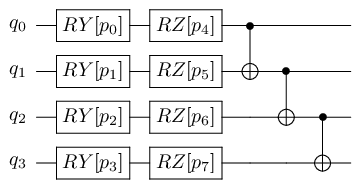


Ansatz: Circular


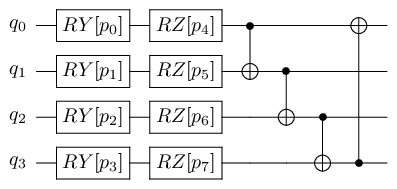


Ansatz: All to All


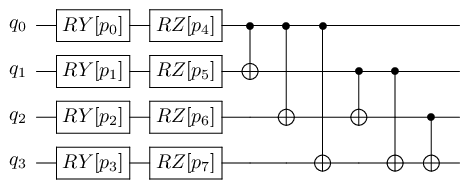


Ansatz: Hardware Efficient


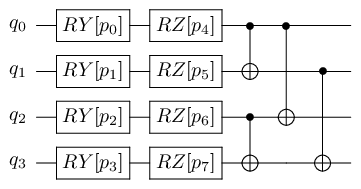

In [7]:
ansatz_specs = {
    "Linear": {"builder": build_ansatz_linear(), "cnot_count": 3},
    "Circular": {"builder": build_ansatz_circular(), "cnot_count": 4},
    "All2All": {"builder": build_ansatz_all_to_all(), "cnot_count": 6},
    "HardwareEfficient": {"builder": build_ansatz_hardware_efficient(), "cnot_count": 4},
}

print("Ansatze prontos:", list(ansatz_specs.keys()))

# Visualizacao separada dos ansatze (sem loop)
circ_ansatz1 = build_ansatz_linear()
print("\nAnsatz: Linear")
circ_ansatz1.display()

circ_ansatz2 = build_ansatz_circular()
print("\nAnsatz: Circular")
circ_ansatz2.display()

circ_ansatz3 = build_ansatz_all_to_all()
print("\nAnsatz: All to All")
circ_ansatz3.display()

circ_ansatz4 = build_ansatz_hardware_efficient()
print("\nAnsatz: Hardware Efficient")
circ_ansatz4.display()

### 6. Funções de execução (VQE ideal e VQE ruidoso)

#### Observação sobre o modelo ruidoso
Para manter o notebook executável em ambiente local padrão, utilize um modelo efetivo de despolarização aplicado diretamente à energia esperada:

$$E_{ruido} = E_{mix} + (1-p_{eff})(E_{ideal} - E_{mix})$$

em que:

 $E_{mix}=Tr(H)/2^n$ e $p_{eff}$ dependente de `p` e da quantidade de CNOTs do ansatz.

### 7. Simulação em cenário ideal

#### Execuçao dos 4 ansatze
Execute o algoritmo VQE para cada um dos ansätze implementados.

In [8]:
def parse_trace(raw_trace):
    if isinstance(raw_trace, str):
        values = ast.literal_eval(raw_trace)
    else:
        values = raw_trace
    return [float(x) for x in values]

def run_vqe_ideal(ansatz_builder, observable, maxiter=180):
    qpu = ScipyMinimizePlugin(
        method="COBYLA",
        tol=1e-6,
        options={"maxiter": maxiter},
        x0=np.arange(0.1, 0.9, 0.1),
    ) | get_default_qpu()

    job = ansatz_builder.to_job(observable=observable)
    result = qpu.submit(job)
    trace = parse_trace(result.meta_data.get("optimization_trace", []))

    return {
        "energy": float(result.value),
        "params": dict(result.parameter_map),
        "trace": trace,
        "iterations": len(trace),
    }

In [9]:
ideal_results = {}

for name, spec in ansatz_specs.items():
    print(f"Executando ideal: {name}")
    res = run_vqe_ideal(spec["builder"], H4, maxiter=180)
    ideal_results[name] = res
    print(f"  Energia final: {res['energy']:.6f} | Iteracoes: {res['iterations']}")

print("Concluido: cenario ideal.")

Executando ideal: Linear
  Energia final: -3.130029 | Iteracoes: 180
Executando ideal: Circular
  Energia final: -3.130000 | Iteracoes: 169
Executando ideal: All2All
  Energia final: -3.147121 | Iteracoes: 180
Executando ideal: HardwareEfficient
  Energia final: -3.134396 | Iteracoes: 180
Concluido: cenario ideal.


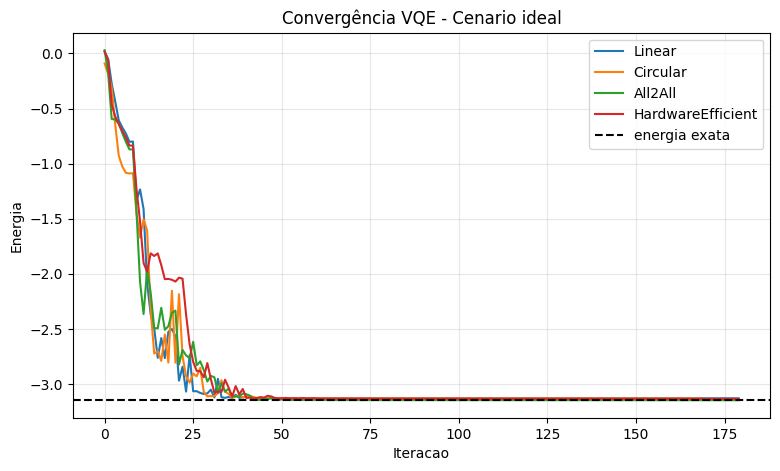

In [10]:
plt.figure(figsize=(9, 5))
for name, res in ideal_results.items():
    plt.plot(res["trace"], label=name)
plt.axhline(exact_energy, linestyle="--", color="black", label="energia exata")
plt.title("Convergência VQE - Cenario ideal")
plt.xlabel("Iteracao")
plt.ylabel("Energia")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### 8. Simulação em cenário ruidoso (canal de despolarização)

#### Parâmetro de ruído
Defina `p` conforme orienção do roteiro *hans on*.

In [11]:
from qat.quops import QuantumChannelKraus
from qat.hardware import HardwareModel, DefaultGatesSpecification
from qat.qpus import NoisyQProc
from qat.plugins import ObservableSplitter

from itertools import product

p_depolar = 0.03  # probabilidade de despolarizacao

# implementacao do ruido
Xmat = np.array([[0, 1], [1, 0]], dtype=complex)
Ymat = np.array([[0, -1j], [1j, 0]], dtype=complex)
Zmat = np.array([[1, 0],  [0, -1]], dtype=complex)

def depolarizing_channel(p):
  return QuantumChannelKraus([
        np.sqrt(1 - p) * np.eye(2, dtype=complex),
        np.sqrt(p/3)   * Xmat,
        np.sqrt(p/3)   * Ymat,
        np.sqrt(p/3)   * Zmat,
  ])

def depolarizing_channel_2q(p):
  ch = depolarizing_channel(p)
  return QuantumChannelKraus([
        np.kron(K1, K2) for K1, K2 in product(ch.kraus_operators, ch.kraus_operators)
  ])

error_1q = depolarizing_channel(p_depolar)
error_2q = depolarizing_channel_2q(p_depolar)

gates_noise_dep = {
    "RY":   lambda *args, **kwargs: error_1q,
    "RZ":   lambda *args, **kwargs: error_1q,
    "CNOT": lambda *args, **kwargs: error_2q,
}

def run_vqe_noise(ansatz_builder, maxiter=180):
    hw  = HardwareModel(DefaultGatesSpecification(), gates_noise_dep, idle_noise=None)
    noisy_qpu = NoisyQProc(hardware_model=hw)
    
    qpu = ScipyMinimizePlugin(
      method="COBYLA",
      tol=1e-6,
      options={"maxiter": maxiter},
      x0=np.arange(0.1, 0.9, 0.1),
      ) | ObservableSplitter() | noisy_qpu

    job = ansatz_builder.to_job(observable=H4)
    result = qpu.submit(job)
    trace = eval(result.meta_data.get("optimization_trace"))

    return {
          "energy": float(result.value),
          "params": dict(result.parameter_map),
          "trace": trace,
          "iterations": len(trace),
    }

In [12]:
noisy_results = {}
for name, spec in ansatz_specs.items():
    print(f"Executando ruído: {name}")
    res = run_vqe_noise(spec["builder"], maxiter=180)
    noisy_results[name] = res
    print(f"  Energia final: {res['energy']:.6f} | Iteracoes: {res['iterations']}")

print("Concluido: cenario com ruído.")

Executando ruído: Linear
  Energia final: -2.749236 | Iteracoes: 180
Executando ruído: Circular
  Energia final: -2.573890 | Iteracoes: 180
Executando ruído: All2All
  Energia final: -2.590223 | Iteracoes: 180
Executando ruído: HardwareEfficient
  Energia final: -2.638733 | Iteracoes: 180
Concluido: cenario com ruído.


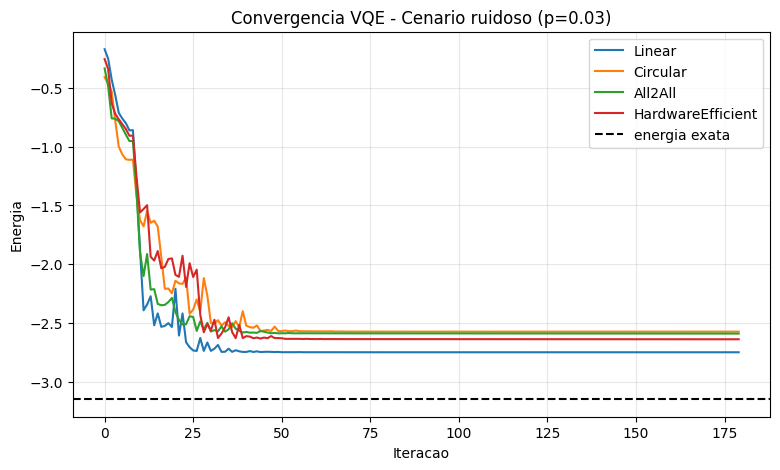

In [13]:
plt.figure(figsize=(9, 5))
for name, res in noisy_results.items():
    plt.plot(res["trace"], label=name)
plt.axhline(exact_energy, linestyle="--", color="black", label="energia exata")
plt.title(f"Convergencia VQE - Cenario ruidoso (p={p_depolar})")
plt.xlabel("Iteracao")
plt.ylabel("Energia")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### 9. Análise comparativa e recomendação

#### Tabela-sintese (8 cenarios)
A tabela a seguir reúne os resultados obtidos para 4 ansatze em 2 condições de execução (ideal e ruidosa).

In [14]:
rows = []
for name in ansatz_specs.keys():
    e_ideal = ideal_results[name]["energy"]
    e_noisy = noisy_results[name]["energy"]

    rows.append({
        "ansatz": name,
        "cenario": "ideal",
        "energia_final": e_ideal,
        "energia_final_ideal": e_ideal,
        "iteracoes": ideal_results[name]["iterations"],
        "erro_abs_vs_exato": abs(e_ideal - exact_energy),
        "delta_vs_ideal": 0.0,
    })

    rows.append({
        "ansatz": name,
        "cenario": "ruidoso",
        "energia_final": e_noisy,
        "energia_final_ideal": e_ideal,
        "iteracoes": noisy_results[name]["iterations"],
        "erro_abs_vs_exato": abs(e_noisy - exact_energy),
        "delta_vs_ideal": abs(e_noisy - e_ideal),
    })

df_results = pd.DataFrame(rows)
df_results = df_results.sort_values(["ansatz", "cenario"]).reset_index(drop=True)
df_results

,ansatz,cenario,energia_final,energia_final_ideal,iteracoes,erro_abs_vs_exato,delta_vs_ideal
0,All2All,ideal,-3.147121,-3.147121,180,0.001490,0.000000
1,All2All,ruidoso,-2.590223,-3.147121,180,0.558388,0.556898
2,Circular,ideal,-3.130000,-3.130000,169,0.018611,0.000000
3,Circular,ruidoso,-2.573890,-3.130000,180,0.574721,0.556110
4,HardwareEfficient,ideal,-3.134396,-3.134396,180,0.014215,0.000000
5,HardwareEfficient,ruidoso,-2.638733,-3.134396,180,0.509878,0.495663
6,Linear,ideal,-3.130029,-3.130029,180,0.018582,0.000000
7,Linear,ruidoso,-2.749236,-3.130029,180,0.399375,0.380793


In [15]:
# Ranking simples de robustez no cenario ruidoso
df_noisy = df_results[df_results["cenario"] == "ruidoso"].copy()
df_noisy = df_noisy.sort_values(["erro_abs_vs_exato", "delta_vs_ideal", "iteracoes"])

best_ansatz = df_noisy.iloc[0]["ansatz"]

print("Energia exata de referencia:", round(exact_energy, 6))
print("Ansatz recomendado (criterio: menor erro + maior robustez):", best_ansatz)
print("\nResumo ruidoso ordenado:")
display(df_noisy)

Energia exata de referencia: -3.148611
Ansatz recomendado (criterio: menor erro + maior robustez): Linear

Resumo ruidoso ordenado:


,ansatz,cenario,energia_final,energia_final_ideal,iteracoes,erro_abs_vs_exato,delta_vs_ideal
7,Linear,ruidoso,-2.749236,-3.130029,180,0.399375,0.380793
5,HardwareEfficient,ruidoso,-2.638733,-3.134396,180,0.509878,0.495663
1,All2All,ruidoso,-2.590223,-3.147121,180,0.558388,0.556898
3,Circular,ruidoso,-2.573890,-3.130000,180,0.574721,0.556110


### 10. Conclusão

Elabore uma conclusão a partir dos resultados obtidos, considerando os pontos indicados a seguir.

### 1. Qual topologia teve melhor compromisso entre precisão e robustez ao ruído?
- O ansatz linear teve o melhor compromisso entre a precisão e robustez ao ruído. Observa-se que em um cenário ideal, todos os ansatze têm erros absolutos muito similares, tais como o menor erro para o All2All (0.001490) e maior erro para o Circular (0.018611). 

- Destaca-se ainda que, ao aumentar o número máximo de iterações para 300, a topologia Circular convergiu rapidamente com 195 iterações. Como o COBYLA está configurado com uma tolerância de $10^{-6}$ e a energia fundamental encontrada no cenário ideal foi de -3.13, é um indicativo que seja um mínimo local, dado que a energia exata é -3.148611.

- No cenário com ruído, o Linear apresenta a menor degradação perante o ideal (delta de 0.380793), sendo cerca de 23% mais robusto que o HardwareEfficient (segundo colocado com delta de 0.495669). Já o Circular teve a pior degradação (delta de 0.556110), seguido de perto pelo All2All (delta de 0.554177).

- Conclui-se com base nesse experimento que o ansatz Linear protege mais contra o acúmulo de ruídos, mesmo tendo uma conectividade reduzida e com pouca expressividade.

### 2. Como a profundidade (quantidade de CNOTs) afetou a degradação por ruído?
- A degradação está diretamente ligada com as portas CNOTs. Os ansatze All2All e Circular têm mais portas CNOTs e, portanto, possuem conectividade mais densa. Por isso, amplificam-se erros de depolarização a cada operação, resultando nos maiores erros absolutos ruidosos da tabela (0.558388 e 0.574721, respectivamente), esgotando o limite de 180 iterações sem se aproximarem do ideal. O ansatz Linear minimiza a profundidade do circuito dado que a conectividade ocorre apenas entre vizinhos, resultando em menos erros acumulados. Por fim, o HardwareEfficient mostrou uma robustez moderada (erro ruidoso de 0.509878), sendo ultrapassado apenas pelo Linear, o que demonstra que o seu design é eficiente para reduzir danos causados pela profundidade em relação a topologias totalmente conectadas.

### 3. Qual ansatz você recomendaria para dispositivo NISQ com topologia de grade?
- Com certeza recomendaríamos o ansatz Linear. Como exemplo, ao considerarmos dispositivos NISQ como os da IBM com topologia em grade, esta já possui conectividade limitada aos seus qubits vizinhos mais próximos. Portanto, o Linear mapeia diretamente a arquitetura desse hardware sem precisar portas extras como as SWAPs. Isso é importante, pois elimina uma camada de profundidade no circuito que os ansatze All2All e HardwareEfficient exigiriam.